In [ ]:
# Install required libraries (Colab pre-installs most, but SHAP needs explicit install)
!pip install -q shap pandas numpy scikit-learn matplotlib seaborn joblib
print(" Dependencies installed successfully")

 Dependencies installed successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Report-ready styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
print(" Environment configured")

 Environment configured


In [8]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [9]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f" Raw Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f" Attrition Distribution:\n{df['Attrition'].value_counts()}")
df.head()

 Raw Dataset: 1470 rows × 35 columns
 Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
# Drop constant & ID columns (no predictive value)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

# Encode target & key categorical
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['OverTime'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].astype(float)

print(f" Cleaned Shape: {df_clean.shape}")
print(f" Dropped: {cols_to_drop}")

 Cleaned Shape: (1470, 31)
 Dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


In [11]:
# 1. Age Group Segmentation
bins = [17, 25, 35, 45, 100]
labels = ['Early Career', 'Core Contributor', 'Senior/Management', 'Executive/Late Career']
df_clean['Age Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, right=False)

# 2. Promotion Gap
df_clean['Promotion Gap'] = df_clean['YearsAtCompany'] - df_clean['YearsSinceLastPromotion']

# 3. Early-Stage Flight Risk Flag (Assumption #2)
df_clean['Early_Stage_Risk'] = (df_clean['YearsInCurrentRole'] < 2).astype(int)

print(" Engineered Features Created:")
df_clean[['Age', 'Age Group', 'Promotion Gap', 'Early_Stage_Risk']].head()

 Engineered Features Created:


,Age,Age Group,Promotion Gap,Early_Stage_Risk
0,41,Senior/Management,6,0
1,49,Executive/Late Career,9,0
2,37,Senior/Management,0,1
3,33,Core Contributor,5,0
4,27,Core Contributor,0,0


In [12]:
total = len(df_clean)
attr_rate = (df_clean['Attrition'].sum() / total) * 100
ot_yes = df_clean[df_clean['OverTime']==1]['Attrition'].mean() * 100
ot_no  = df_clean[df_clean['OverTime']==0]['Attrition'].mean() * 100
ot_mult = ot_yes / ot_no
inc_left = df_clean[df_clean['Attrition']==1]['MonthlyIncome'].mean()
inc_stay = df_clean[df_clean['Attrition']==0]['MonthlyIncome'].mean()

print("Section 13 KPI Verification:")
print(f"• Total Employees: {total:,}")
print(f"• Attrition Rate: {attr_rate:.1f}% (Report: 16.1%)")
print(f"• Overtime Attrition Multiplier: {ot_mult:.1f}x (Report: ~3.0x)")
print(f"• Avg Income (Left): ${inc_left:,.0f} (Report: $4,787)")
print(f"• Avg Income (Stayed): ${inc_stay:,.0f} (Report: $6,832)")

Section 13 KPI Verification:
• Total Employees: 1,470
• Attrition Rate: 16.1% (Report: 16.1%)
• Overtime Attrition Multiplier: 2.9x (Report: ~3.0x)
• Avg Income (Left): $4,787 (Report: $4,787)
• Avg Income (Stayed): $6,833 (Report: $6,832)


In [14]:
from sklearn.model_selection import train_test_split

y = df_clean['Attrition']
X = df_clean.drop(columns=['Attrition'])

# One-hot encode categoricals for ML
X_encoded = pd.get_dummies(X, drop_first=True)

# Stratified split (preserves 84:16 imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)
print(f" Train: {X_train.shape} | Test: {X_test.shape}")

 Train: (1176, 49) | Test: (294, 49)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Train RF with balanced class weights
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions & Metrics
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f" Random Forest Performance:")
print(f"   F1-Score : {f1_score(y_test, y_pred):.3f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

 Random Forest Performance:
   F1-Score : 0.194
   ROC-AUC  : 0.765

 Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.96      0.90       247
        Left       0.40      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.55       294
weighted avg       0.78      0.83      0.79       294



<Figure size 1000x600 with 0 Axes>

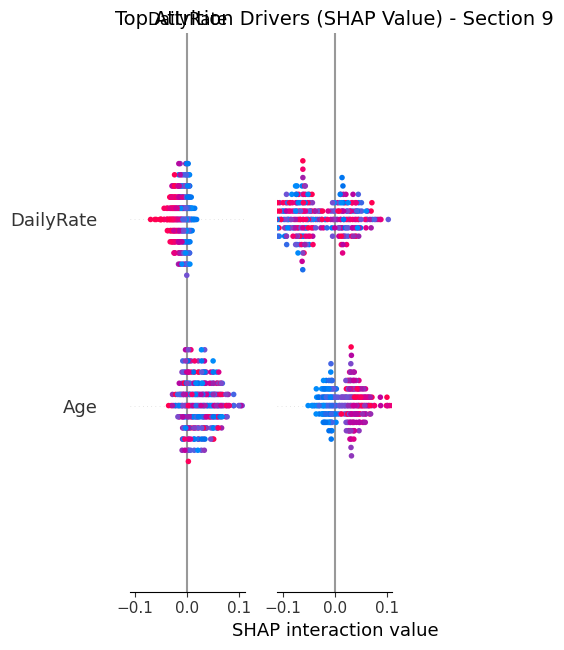

 SHAP plot saved as 'shap_drivers.png' (Ready for Power BI Insert → Image)


In [19]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Plot & Save for Power BI
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Attrition Drivers (SHAP Value) - Section 9", fontsize=14)
plt.tight_layout()
plt.savefig('shap_drivers.png', bbox_inches='tight')
plt.show()
print(" SHAP plot saved as 'shap_drivers.png' (Ready for Power BI Insert → Image)")

/tmp/ipykernel_7946/2063983620.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Left'])
/tmp/ipykernel_7946/2063983620.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])
/tmp/ipykernel_7946/2063983620.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Stayed', 'Left'])


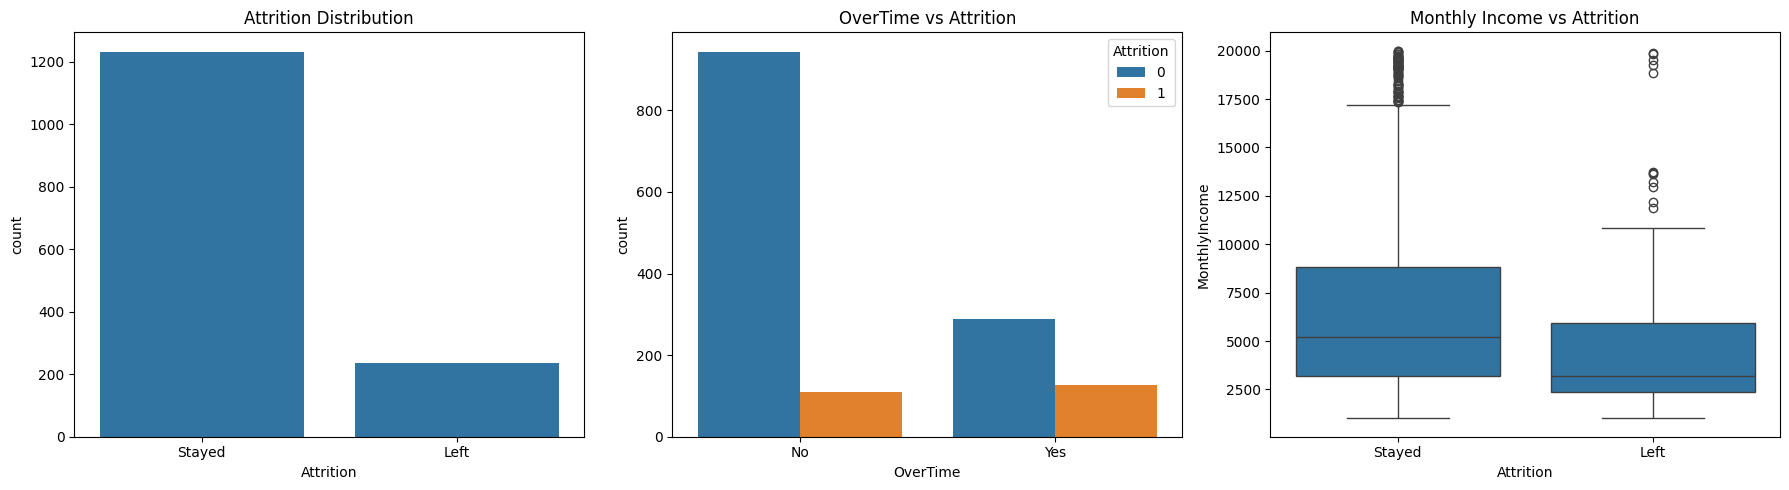

In [21]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Attrition Distribution
sns.countplot(x='Attrition', data=df_clean, ax=axes[0])
axes[0].set_title('Attrition Distribution')
axes[0].set_xticklabels(['Stayed', 'Left'])

# 2. OverTime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df_clean, ax=axes[1])
axes[1].set_title('OverTime vs Attrition')
axes[1].set_xticklabels(['No', 'Yes'])

# 3. Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, ax=axes[2])
axes[2].set_title('Monthly Income vs Attrition')
axes[2].set_xticklabels(['Stayed', 'Left'])

plt.tight_layout()
plt.savefig('eda_visuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Add full dataset predictions for HR export
df_clean['Risk_Score'] = rf.predict_proba(X_encoded)[:, 1]
df_clean['Predicted_Attrition'] = (df_clean['Risk_Score'] > 0.3).astype(int)

# Save cleaned dataset
df_clean.to_csv('cleaned_hr_data.csv', index=False)
print(" Cleaned dataset saved with predictions")

# Download files to local machine (matches GitHub structure)
from google.colab import files
files.download('cleaned_hr_data.csv')
files.download('shap_drivers.png')
files.download('eda_visuals.png')
print(" Files downloaded. Move to your GitHub repo folders.")

 Cleaned dataset saved with predictions


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Files downloaded. Move to your GitHub repo folders.


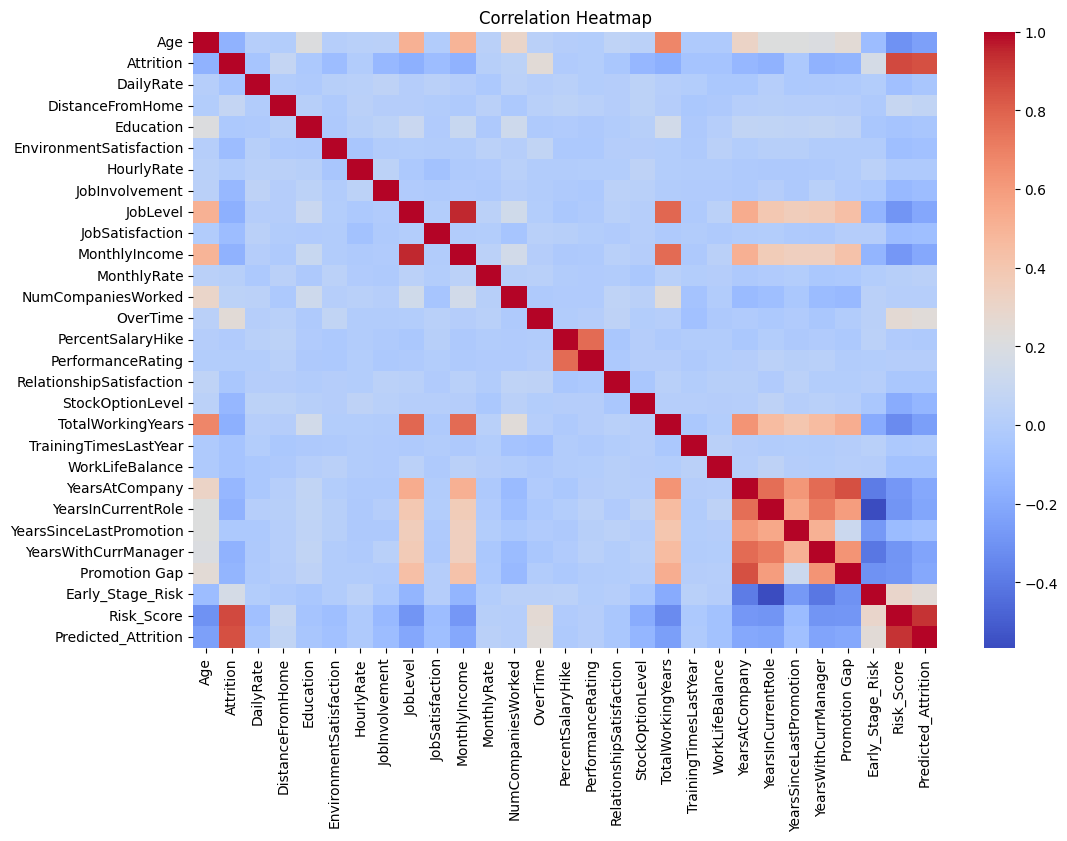

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

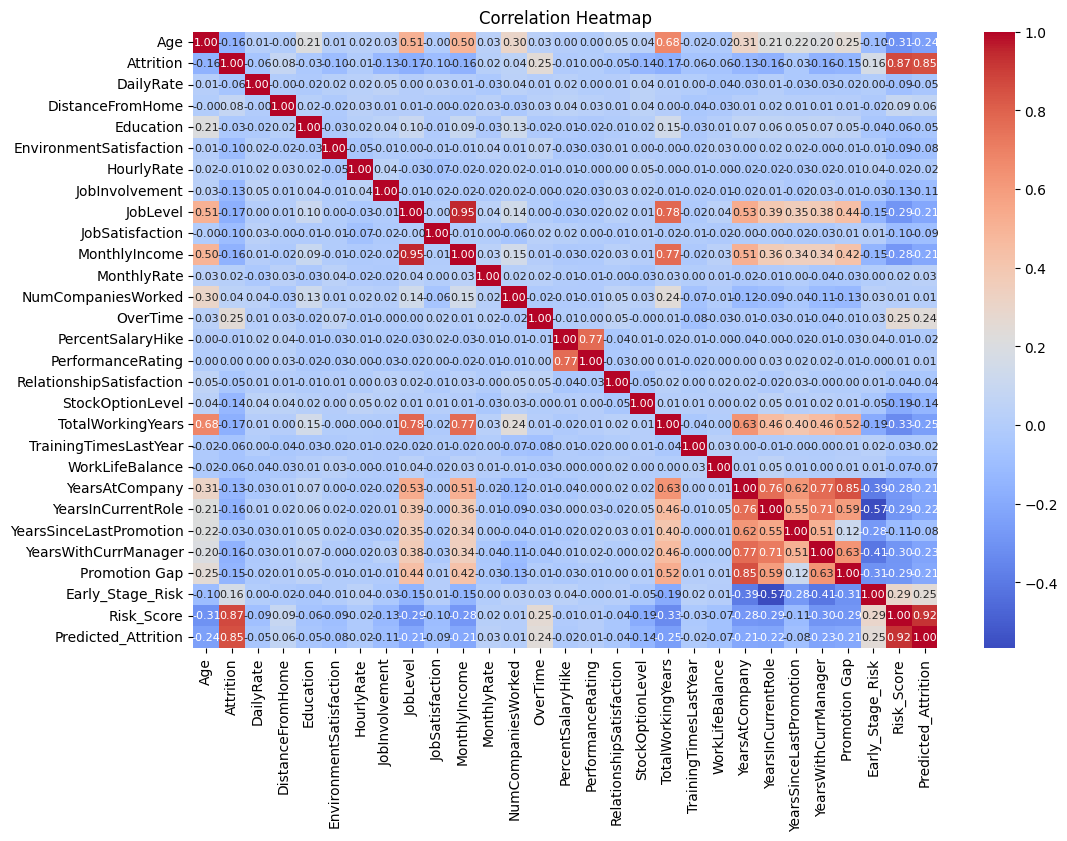

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt='.2f', annot_kws={'size':8})
plt.title("Correlation Heatmap")
plt.show()

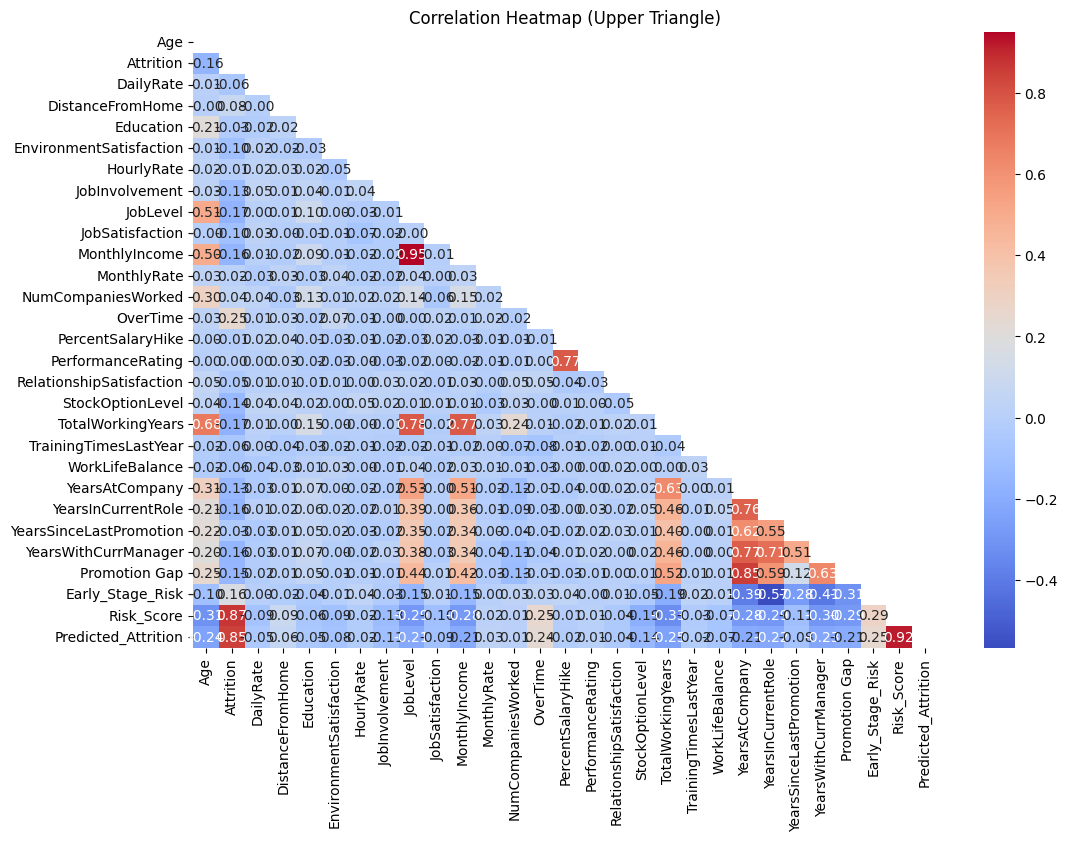

In [30]:
import numpy as np
plt.figure(figsize=(12,8))
corr_matrix = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap (Upper Triangle)")
plt.show()

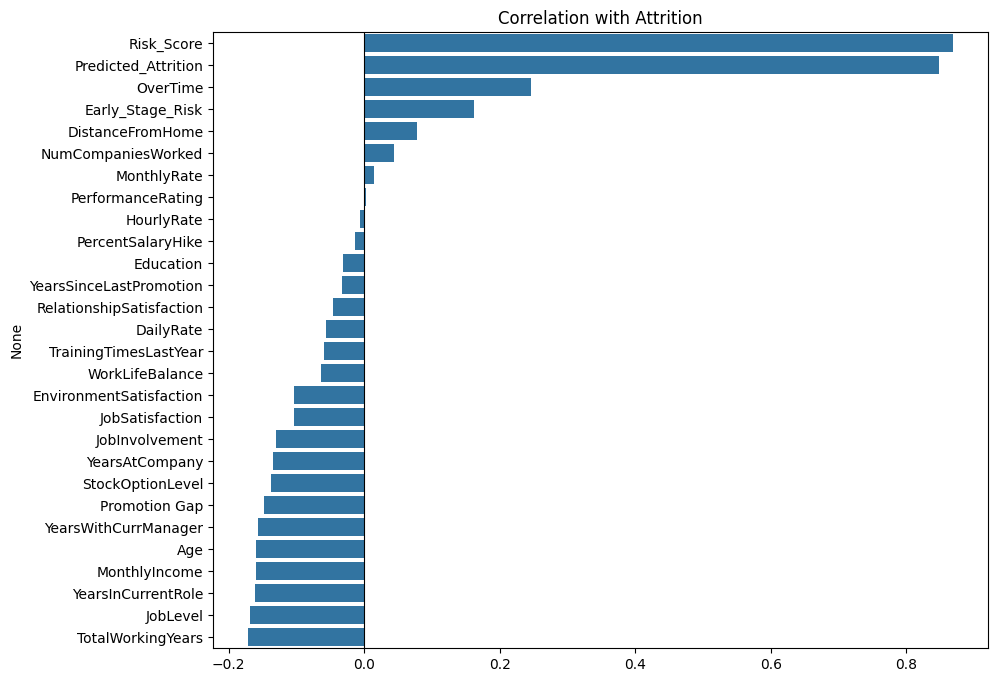

In [32]:
plt.figure(figsize=(10,8))
corr_with_attrition = df_clean.corr(numeric_only=True)['Attrition'].sort_values(ascending=False).drop('Attrition')
sns.barplot(x=corr_with_attrition.values, y=corr_with_attrition.index)
plt.title("Correlation with Attrition")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()